This notebook is only to see the catboost regressor of the RNAseq z-score combat (withour ridge)

In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
import getting_threshold_genes as gtg
from sklearn.model_selection import train_test_split
import model as m
import divide_bins as divide
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import feature_selection as fs
import pickle

2024-05-27 09:38:46.001820: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-27 09:38:46.023265: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-27 09:38:46.130203: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-27 09:38:46.130248: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-27 09:38:46.148507: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
fit=False

In [3]:
eigth_bins = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_SMOTE_SMOTE_8_b.csv")
eigth_bins.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.027196,-0.031684,-0.001005,-0.029161,-0.029152,-0.031145,-0.022870,-0.028542,-0.023569,-0.027138,...,-0.031746,-0.031568,-0.031728,-0.031280,-0.030700,-0.031722,-0.031747,-0.028999,-0.031495,71-72
1,-0.017960,-0.025238,-0.004623,-0.023480,-0.023654,-0.024793,-0.019915,-0.022223,-0.020463,-0.022694,...,-0.025233,-0.025066,-0.025206,-0.025120,-0.025112,-0.025200,-0.025239,-0.028055,-0.025034,72-95
2,-0.023509,-0.027209,-0.007440,-0.025756,-0.025439,-0.026228,-0.020806,-0.020602,-0.022891,-0.023687,...,-0.027264,-0.027278,-0.027292,-0.027227,-0.026625,-0.027285,-0.027258,-0.025183,-0.026903,50-65
3,-0.028414,-0.032553,-0.001362,-0.028270,-0.029386,-0.032315,-0.027363,-0.028447,-0.024889,-0.028220,...,-0.032615,-0.032625,-0.032598,-0.032513,-0.031188,-0.032593,-0.032616,-0.029468,-0.032476,71-72
4,-0.025459,-0.030208,-0.001516,-0.026133,-0.027908,-0.029627,-0.020931,-0.025970,-0.022807,-0.024564,...,-0.030213,-0.030210,-0.030236,-0.030152,-0.027916,-0.030232,-0.030207,-0.029553,-0.029378,35-50


In [4]:
seq_y_train_cat_a=eigth_bins["Age"]
seq_y_train_a = pd.Series(seq_y_train_cat_a).str.split('-')
seq_y_train_a = seq_y_train_a.apply(lambda x: (int(x[0]) + int(x[1])) / 2)

y_noise = np.random.normal(0, 2, seq_y_train_a.shape)
seq_y_train_a = seq_y_train_a + y_noise
seq_y_train_a = seq_y_train_a.round(0)

dataset = eigth_bins.copy()
dataset["Age"]=seq_y_train_a
dataset.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.027196,-0.031684,-0.001005,-0.029161,-0.029152,-0.031145,-0.022870,-0.028542,-0.023569,-0.027138,...,-0.031746,-0.031568,-0.031728,-0.031280,-0.030700,-0.031722,-0.031747,-0.028999,-0.031495,72.0
1,-0.017960,-0.025238,-0.004623,-0.023480,-0.023654,-0.024793,-0.019915,-0.022223,-0.020463,-0.022694,...,-0.025233,-0.025066,-0.025206,-0.025120,-0.025112,-0.025200,-0.025239,-0.028055,-0.025034,84.0
2,-0.023509,-0.027209,-0.007440,-0.025756,-0.025439,-0.026228,-0.020806,-0.020602,-0.022891,-0.023687,...,-0.027264,-0.027278,-0.027292,-0.027227,-0.026625,-0.027285,-0.027258,-0.025183,-0.026903,57.0
3,-0.028414,-0.032553,-0.001362,-0.028270,-0.029386,-0.032315,-0.027363,-0.028447,-0.024889,-0.028220,...,-0.032615,-0.032625,-0.032598,-0.032513,-0.031188,-0.032593,-0.032616,-0.029468,-0.032476,72.0
4,-0.025459,-0.030208,-0.001516,-0.026133,-0.027908,-0.029627,-0.020931,-0.025970,-0.022807,-0.024564,...,-0.030213,-0.030210,-0.030236,-0.030152,-0.027916,-0.030232,-0.030207,-0.029553,-0.029378,41.0


In [5]:
X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=0.07)
#random_strength

# Initialize CatBoostClassifier
seq_regressor = CatBoostRegressor(iterations=4000,
                                  learning_rate=0.005,
                                  depth=4,
                                  random_state=42,
                                  verbose=1,
                                  od_type='Iter',
                                  od_wait=50,
                                  penalties_coefficient=50,
                                  l2_leaf_reg=5,  # Adjust regularization
                                  random_strength=0.7,
                                  ) 

# Fit the model
if fit:
    seq_regressor.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=True)

In [6]:
if fit:
    # Specify the file path where you want to save the pickle file
    file_path = '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_8_seq_regressor.pkl'

    # Save the seq_regressor variable in the pickle file
    with open(file_path, 'wb') as f:
        pickle.dump(seq_regressor, f)
else:

    # Specify the file path where the pickle file is located
    file_path = '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_8_seq_regressor.pkl'

    # Load the seq_regressor object from the pickle file
    with open(file_path, 'rb') as f:
        seq_regressor = pickle.load(f)

    # Now you can use the seq_regressor object in your code


In [7]:
# Make predictions
y_pred = seq_regressor.predict(X_test)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
seq_mse

82.36752275216715

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate R2
r2 = r2_score(y_test, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 82.36752275216715
RMSE: 9.075655499861547
MAE: 5.60833000257829
R2: 0.8032314869224331


In [9]:
age_ranges_list=[18, 26, 35, 50, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(y_test, age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 2},
 {'label': '26-35', 'range': (26, 35), 'count': 5},
 {'label': '35-50', 'range': (35, 50), 'count': 1},
 {'label': '50-65', 'range': (50, 65), 'count': 5},
 {'label': '65-71', 'range': (65, 71), 'count': 3},
 {'label': '71-72', 'range': (71, 72), 'count': 2},
 {'label': '72-95', 'range': (72, 95), 'count': 5}]

In [10]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[0, 1, 0, 1, 0, 0, 0],
       [1, 3, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 5, 0, 0, 0],
       [0, 0, 0, 0, 3, 0, 0],
       [0, 0, 0, 1, 1, 0, 0],
       [0, 0, 0, 1, 1, 0, 3]])

In [11]:
seq_auc=accuracy_score(c_y_test.round(0), c_y_pred.round(0))
seq_auc

0.6521739130434783

In [12]:
y_test

292    68.0
297    82.0
19     71.0
275    70.0
167    19.0
181    32.0
84     68.0
135    72.0
65     28.0
127    71.0
2      57.0
178    31.0
305    83.0
112    72.0
28     45.0
189    30.0
35     61.0
234    54.0
252    58.0
259    59.0
1      84.0
141    29.0
54     23.0
Name: Age, dtype: float64

In [13]:
seq_results

,Actual,Predicted
292,68.0,68.678412
297,82.0,84.429773
19,71.0,68.958990
275,70.0,68.441844
167,19.0,29.857768
181,32.0,30.717667
84,68.0,68.848172
135,72.0,58.689407
65,28.0,41.594758
127,71.0,63.239167


/tmp/ipykernel_8504/659211106.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


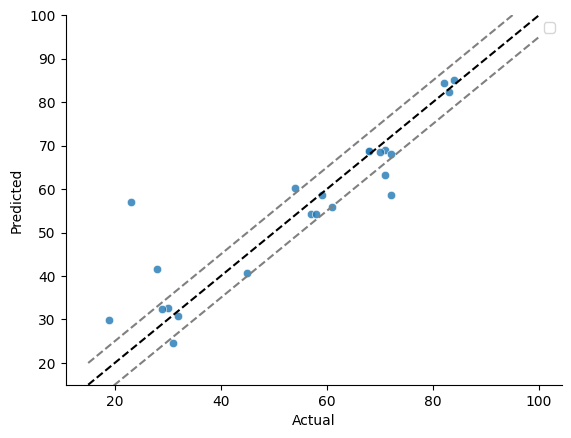

In [14]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [15]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[0, 1, 0, 1, 0, 0, 0],
       [1, 3, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 5, 0, 0, 0],
       [0, 0, 0, 0, 3, 0, 0],
       [0, 0, 0, 1, 1, 0, 0],
       [0, 0, 0, 1, 1, 0, 3]])

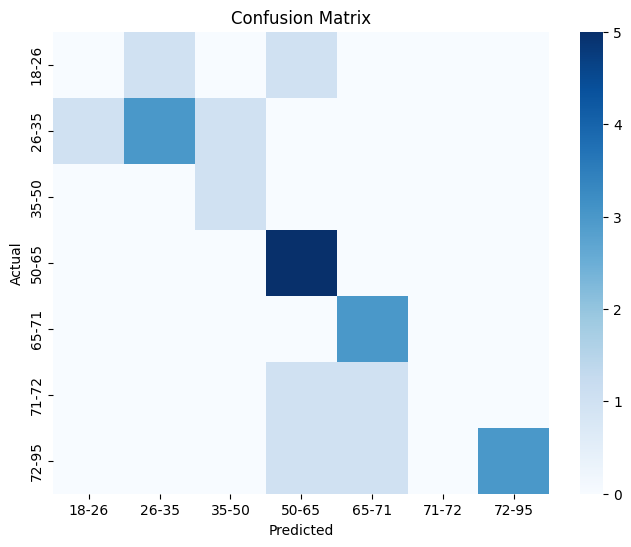

In [16]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [17]:
eigth_bins_test = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_test.csv")
eigth_bins_test.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Sample,Experiment
0,-0.022199,-0.024329,-0.003773,-0.024342,-0.023168,-0.023118,-0.019650,-0.021929,-0.022809,-0.023842,...,-0.024369,-0.024371,-0.023585,-0.024358,-0.024395,-0.023025,-0.024297,24.0,SRR12604218,GSE157585
1,-0.020040,-0.021205,-0.004026,-0.020311,-0.020125,-0.021354,-0.018610,-0.019685,-0.018587,-0.019628,...,-0.021322,-0.021221,-0.021747,-0.021319,-0.021378,-0.022606,-0.021146,18.0,SRR13759023,GSE167186
2,-0.025774,-0.027019,-0.004049,-0.024784,-0.023620,-0.026312,-0.020406,-0.022771,-0.020741,-0.023250,...,-0.026922,-0.026842,-0.026598,-0.026915,-0.026944,-0.020781,-0.026752,23.0,SRR13759025,GSE167186
3,-0.026286,-0.031094,0.001080,-0.029463,-0.029558,-0.029211,-0.020112,-0.026330,-0.020258,-0.028490,...,-0.030938,-0.030771,-0.028873,-0.030937,-0.030940,-0.030323,-0.030942,26.4,SRR1555206,GSE60590
4,-0.021510,-0.026220,0.001219,-0.022533,-0.023448,-0.025671,-0.014182,-0.018851,-0.015137,-0.019720,...,-0.026261,-0.026039,-0.026443,-0.026252,-0.026286,-0.024934,-0.026092,71.0,SRR12604184,GSE157585


In [18]:
age_ranges_list=[18, 26, 35, 50, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(eigth_bins_test["Age"], age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 13},
 {'label': '26-35', 'range': (26, 35), 'count': 23},
 {'label': '35-50', 'range': (35, 50), 'count': 8},
 {'label': '50-65', 'range': (50, 65), 'count': 9},
 {'label': '65-71', 'range': (65, 71), 'count': 9},
 {'label': '71-72', 'range': (71, 72), 'count': 25},
 {'label': '72-95', 'range': (72, 95), 'count': 21}]

In [19]:
X_test_untoached = eigth_bins_test.drop(columns=["Age"])
X_test_untoached.drop(columns=["Experiment", "Sample"], inplace=True)
y_test_untoached = eigth_bins_test["Age"]
seq_z_test = eigth_bins_test["Experiment"]

In [20]:
seq_z_test = pd.DataFrame(seq_z_test)
seq_z_test.columns = ["Experiment"]

In [21]:
# Make predictions
y_pred = seq_regressor.predict(X_test_untoached)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test_untoached, y_pred)
seq_results = pd.DataFrame({'Actual': y_test_untoached, 'Predicted': y_pred})
seq_mse

185.89638406247437

/tmp/ipykernel_8504/659211106.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


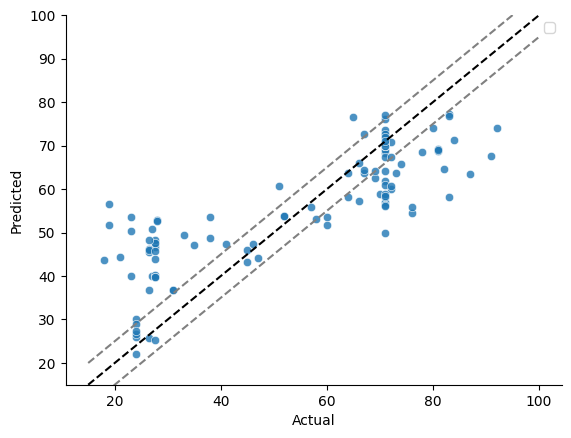

In [22]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

     Actual  Predicted Experiment
0      24.0  26.062737  GSE157585
1      18.0  43.690989  GSE167186
2      23.0  50.308161  GSE167186
3      26.4  45.528963   GSE60590
4      71.0  76.093072  GSE157585
..      ...        ...        ...
103    71.0  71.938919  GSE157585
104    23.0  53.646126  GSE167186
105    72.0  60.755990  GSE164471
106    71.0  71.145137  GSE157585
107    71.0  49.956607  GSE167186

[108 rows x 3 columns]


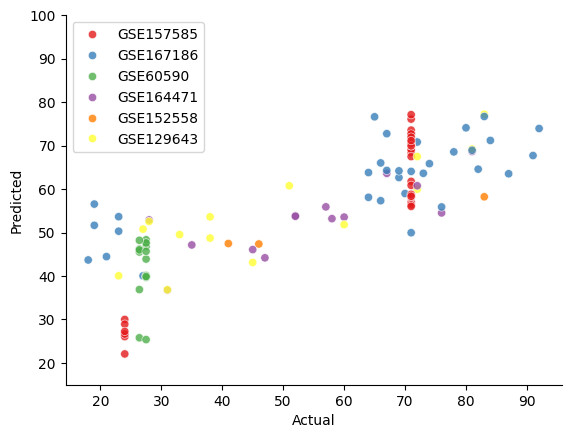

In [23]:
m.plot_results(results=seq_results, labels=seq_z_test)

In [24]:
c_y_test = pd.Series(y_test_untoached).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[ 1,  5,  3,  4,  0,  0,  0],
       [ 2,  0, 18,  3,  0,  0,  0],
       [ 0,  0,  7,  1,  0,  0,  0],
       [ 0,  0,  0,  9,  0,  0,  0],
       [ 0,  0,  0,  6,  1,  0,  2],
       [ 0,  0,  1,  9,  8,  2,  5],
       [ 0,  0,  0,  8,  8,  1,  4]])

In [25]:
acu = accuracy_score(c_y_test, c_y_pred)
acu

0.2222222222222222

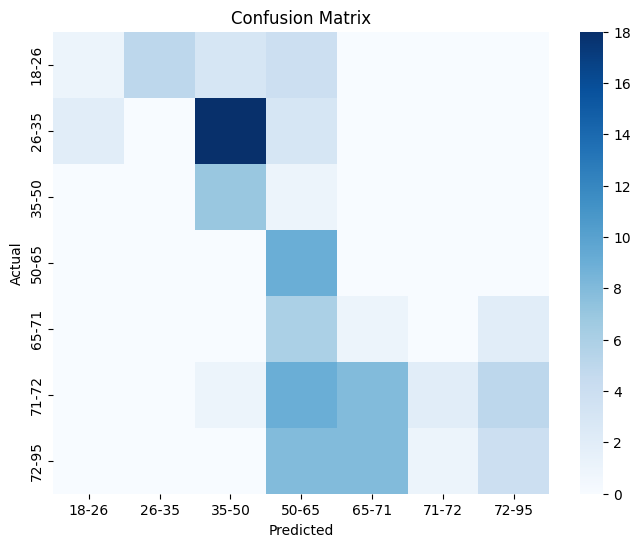

In [26]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test_untoached, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test_untoached, y_pred)

# Calculate R2
r2 = r2_score(y_test_untoached, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 185.89638406247437
RMSE: 13.634382423215008
MAE: 10.673559374667507
R2: 0.6286951056235448


In [28]:
explainer = shap.Explainer(seq_regressor)
shap_values = explainer.shap_values(X_test)
importance = seq_regressor.get_feature_importance()
feature_imporance_df = pd.DataFrame(importance, index=X_test.columns, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)
feature_imporance_df

,importance
ENSG00000101892.11,15.948722
ENSG00000201766.1,3.013744
ENSG00000127241.16,2.966901
ENSG00000277654.5,2.289820
ENSG00000145949.10,2.131209
...,...
ENSG00000166689.15,0.000013
ENSG00000138081.20,0.000012
ENSG00000197265.8,0.000009
ENSG00000134363.11,0.000008


In [38]:
feature_imporance_df.head(15)

,importance
ENSG00000101892.11,15.948722
ENSG00000201766.1,3.013744
ENSG00000127241.16,2.966901
ENSG00000277654.5,2.289820
ENSG00000145949.10,2.131209
ENSG00000171055.14,1.773266
ENSG00000198712.1,1.683772
ENSG00000164104.11,1.670869
ENSG00000172399.5,1.502796
ENSG00000177548.12,1.251597


In [33]:
gene_names = [
    ("ENSG00000101892.11", "ATP1B4"),
    ("ENSG00000201766.1", "RNA5SP302"),
    ("ENSG00000127241.16", "MASP1"),
    ("ENSG00000277654.5", "AC087633.2"),
    ("ENSG00000145949.10", "MYLK4"),
    ("ENSG00000171055.14", "FEZ2"),
    ("ENSG00000198712.1", "MT-CO2"),
    ("ENSG00000164104.11", "HMGB2"),
    ("ENSG00000172399.5", "MYOZ2"),
    ("ENSG00000177548.12", "RABEP2"),
    ("ENSG00000089101.17", "CFAP61"),
    ("ENSG00000003989.17", "SLC7A2"),
    ("ENSG00000137700.17", "SLC37A4"),
    ("ENSG00000174227.15", "PIGG"),
    ("ENSG00000133020.4", "MYH8"),
    ("ENSG00000252262.1", "RNA5SP61"),
    ("ENSG00000234441.1", "AC105272.1"),
    ("ENSG00000247627.2", "MTND4P12"),
    ("ENSG00000100568.10", "VTI1B"),
    ("ENSG00000237973.1", "MTCO1P12"),
    ("ENSG00000178053.17", "MLF1"),
    ("ENSG00000134056.11", "MRPS36"),
    ("ENSG00000276045.3", "ORAI1"),
    ("ENSG00000007944.14", "MYLIP"),
    ("ENSG00000029725.16", "RABEP1"),
    ("ENSG00000145414.8", "NAF1"),
    ("ENSG00000257542.5", "OR7E47P"),
    ("ENSG00000163322.13", "ABRAXAS1"),
    ("ENSG00000134684.10", "YARS"),
    ("ENSG00000108349.16", "CASC3"),
    ("ENSG00000127184.12", "COX7C"),
    ("ENSG00000172456.17", "FGGY"),
    ("ENSG00000249780.1", "AC093809.1"),
    ("ENSG00000107890.16", "ANKRD26"),
    ("ENSG00000082153.17", "BZW1"),
    ("ENSG00000177606.6", "JUN"),
    ("ENSG00000160961.11", "ZNF333"),
    ("ENSG00000169926.10", "KLF13"),
    ("ENSG00000222922.1", "RNA5SP501"),
    ("ENSG00000104904.12", "OAZ1"),
    ("ENSG00000169083.16", "AR"),
    ("ENSG00000101400.5", "SNTA1"),
    ("ENSG00000172159.15", "FRMD3"),
    ("ENSG00000112531.16", "QKI"),
    ("ENSG00000229344.1", "MTCO2P12"),
    ("ENSG00000105048.16", "TNNT1"),
    ("ENSG00000123095.5", "BHLHE41"),
    ("ENSG00000125351.11", "UPF3B"),
    ("ENSG00000270388.1", "MTCO3P22"),
    ("ENSG00000004961.14", "HCCS")
]


for gene_id, gene_name in gene_names:
    if gene_id in X_test.columns:
        X_test.rename(columns={gene_id: gene_name}, inplace=True)


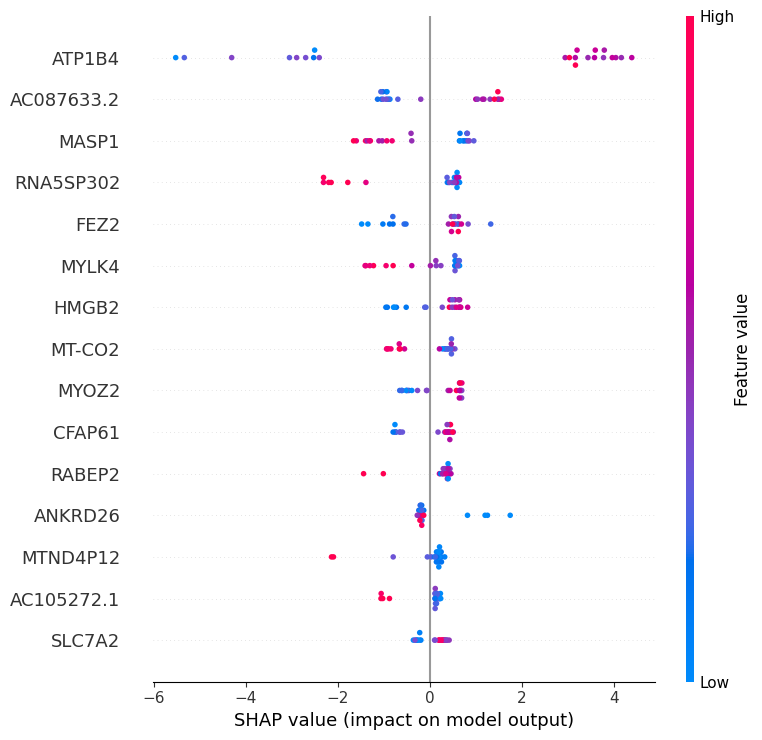

In [37]:
shap.summary_plot(shap_values, X_test, max_display=15)


In [32]:
mcc = matthews_corrcoef(c_y_test, c_y_pred)
mcc

0.15058219479484738